## Atenuación del halo en frames IR
### Objetivo:
Separar la huella del melt-pool de la sombra de irradiación que la rodea, comparando cuatro filtros de OpenCV y SciPy, elegir la configuración más adecuada para nuestro dataset y justificar la elección con métricas, no solo con la apariencia de la imagen.
### Integrantes: 
Junior Anchundia, Jeremy Garzon, Noelia Quishpe

### Librerías

In [1]:
from pathlib import Path
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy import ndimage as ndi  
import pandas as pd
from concurrent.futures import ThreadPoolExecutor
import shutil
import time
from PIL import Image

### Definición de directorios

In [2]:
CODE_DIR = Path.cwd().resolve()
PROJECT_ROOT = CODE_DIR.parent
DATA_DIR = PROJECT_ROOT / "Data"
images_dir = DATA_DIR / "images"
output_dir = DATA_DIR / "images_trabajo"

print(f"Directorio de imágenes: {images_dir}")
print(f"Directorio de salida: {output_dir}")

Directorio de imágenes: C:\IA\CursoIA\Data\images
Directorio de salida: C:\IA\CursoIA\Data\images_trabajo


### Funciones Auxiliares

In [3]:
def leer_frame(ruta):
    """Lee un frame TIFF y retorna como array"""
    img = cv2.imread(str(ruta), cv2.IMREAD_UNCHANGED)
    return img


def analizar_frame(ruta, umbral_pixel=10):
    """Analiza un frame y retorna estadísticas básicas"""
    img = leer_frame(ruta)

    if img is None:
        return None

    return {
        "ruta": ruta,
        "archivo": ruta.name,
        "media": float(np.mean(img)),
        "maximo": int(np.max(img)),
        "pct_activos": float(np.mean(img > umbral_pixel) * 100)
    }


def calcular_iou(mascara_ref, huella):
    """Calcula IoU entre dos máscaras binarias"""
    interseccion = np.logical_and(mascara_ref, huella).sum()
    union = np.logical_or(mascara_ref, huella).sum()
    return interseccion / union if union > 0 else 0

def disco(r):
    """Crea elemento estructurante circular"""
    y, x = np.ogrid[-r:r + 1, -r:r + 1]
    return x**2 + y**2 <= r**2

## Selección de Imágenes para trabajar

In [4]:
# Listar todos los frames TIFF
archivos = sorted(images_dir.glob("*.tiff*"))
print(f"Frames encontrados: {len(archivos)}")

Frames encontrados: 41645


In [5]:
# Lectura paralela para obtener estadísticas
num_workers = 8
umbral_pixel = 10

with ThreadPoolExecutor(max_workers=num_workers) as executor:
    resultados = list(
        executor.map(
            lambda ruta: analizar_frame(ruta, umbral_pixel),
            archivos
        )
    )

df = pd.DataFrame(resultados)
print(df.describe())

              media        maximo   pct_activos
count  41645.000000  41645.000000  41645.000000
mean     351.057731  10448.307744      5.099702
std      371.751945  11333.167617      5.392978
min        0.000000      0.000000      0.000000
25%        0.000000      0.000000      0.000000
50%        0.000000      0.000000      0.000000
75%      743.172373  20896.000000     10.830500
max     1320.813555  65520.000000     12.241733


In [6]:
# Separar imágenes útiles (con señal láser)
df_utiles = df[df["maximo"] > 0].copy()

print(f"Total de frames: {len(df)}")
print(f"Frames útiles (con láser): {len(df_utiles)}")
print(f"Frames negros: {len(df) - len(df_utiles)}")

Total de frames: 41645
Frames útiles (con láser): 19864
Frames negros: 21781


In [7]:
# Generar muestra balanceada por % de píxeles activos
df_utiles["grupo"] = pd.cut(
    df_utiles["pct_activos"],
    bins=[0, 2, 6, 10, 100],
    labels=["muy_poco", "poco", "medio", "alto"]
)

muestra_df = (
    df_utiles
    .groupby("grupo", observed=True, group_keys=False)
    .apply(lambda x: x.sample(n=min(75, len(x)), random_state=42))
)

muestra = muestra_df["ruta"].tolist()
print(f"Tamaño de muestra: {len(muestra)} frames")

Tamaño de muestra: 300 frames


In [8]:
# Almacenar imágenes de muestra
output_dir.mkdir(parents=True, exist_ok=True)

for ruta in muestra:
    destino = output_dir / ruta.name
    shutil.copy2(ruta, destino)

print(f"Imágenes copiadas a: {output_dir}")

Imágenes copiadas a: C:\IA\CursoIA\Data\images_trabajo


## Definición de Máscaras de Referencia

Se utilizan 2 frames:
1. **Frame 1 (1764596853908.tiff)**: Nota.- no observamos en el aula virtual que se proporcione la mascara referencia, por lo que se toma la calculada en clase, con una mejora aplicada.
2. **Frame 2**: Máscara marcada manualmente

In [9]:
# FRAME 1: MÁSCARA DE REFERENCIA (1764596853908.tiff)
ruta_frame1 = next((p for p in archivos if p.name == "1764596853908.tiff"), None)

frame1 = leer_frame(ruta_frame1).astype(np.float32)

fs1 = ndi.gaussian_filter(frame1, 1.5)
# Generar máscara por umbral
fondo = float(np.median(frame1))
pico = float(frame1.max())
ALFA = 0.30
UMBRAL = fondo + ALFA * (pico - fondo)
    
mascara_inicial = fs1 > UMBRAL

# Cerrar pequeñas separaciones
mascara_cerrada = ndi.binary_closing(mascara_inicial,structure=disco(5))
# Rellenar huecos internos
mascara_frame1 = ndi.binary_fill_holes(mascara_cerrada)

print(f"Umbral calculado: {UMBRAL:.0f}")
print(f"Píxeles en máscara: {mascara_frame1.sum()}")

Umbral calculado: 5899
Píxeles en máscara: 21122


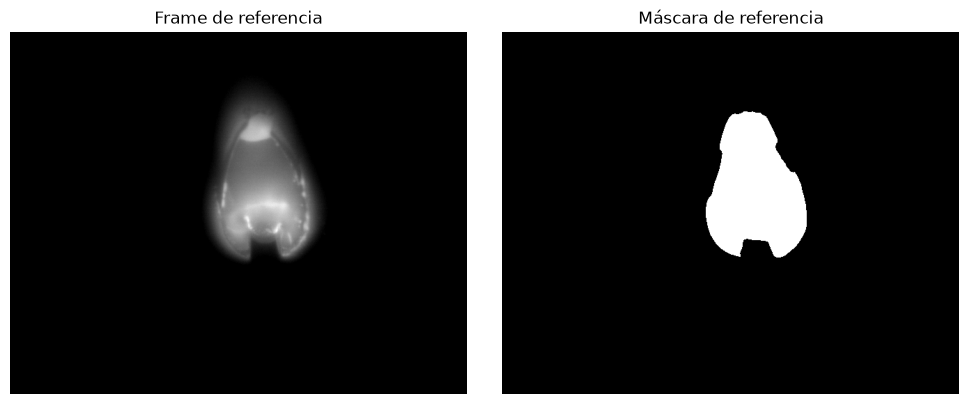

In [10]:
# Visualizar Frame 1 y su máscara
fig, ax = plt.subplots(1, 2, figsize=(10,4))

ax[0].imshow(frame1, cmap="gray")
ax[0].set_title("Frame de referencia")
ax[0].axis("off")

ax[1].imshow(mascara_frame1, cmap="gray")
ax[1].set_title("Máscara de referencia")
ax[1].axis("off")

plt.tight_layout()
plt.show()

Para generar la máscara manual, como equipo se tomo la estrategia de dibujar directamente el contorno de la huella en Paint. Una vez reconocida y delimitada la zona, la importamos al análisis en Python para usarla como referencia.

In [11]:
frame2 = leer_frame(muestra[-1]).astype(np.float32)
mascara_frame2 = np.array(Image.open(DATA_DIR / "mascara_manual.png").convert("L")) > 128

print(frame2.shape, mascara_frame2.shape)

(520, 656) (520, 656)


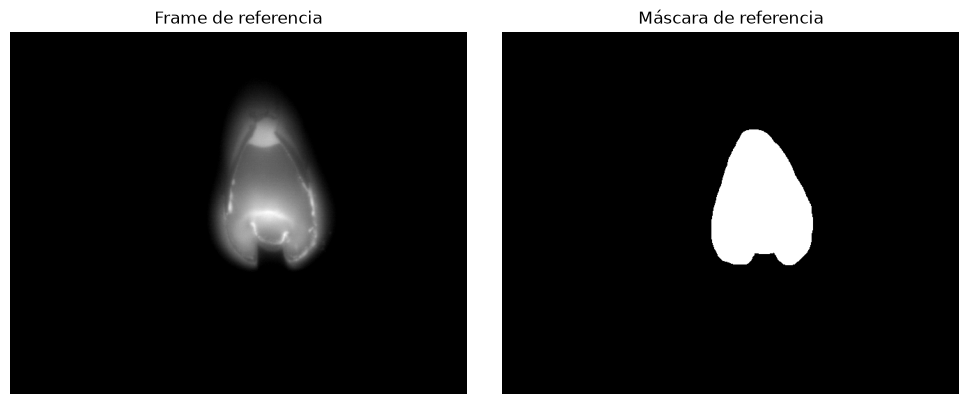

In [12]:
# Visualizar Frame 1 y su máscara
fig, ax = plt.subplots(1, 2, figsize=(10,4))

ax[0].imshow(frame2, cmap="gray")
ax[0].set_title("Frame de referencia")
ax[0].axis("off")

ax[1].imshow(mascara_frame2, cmap="gray")
ax[1].set_title("Máscara de referencia")
ax[1].axis("off")

plt.tight_layout()
plt.show()

## Definición de Filtros

In [13]:
def filtro_maximo(frame, K):
    """NDI Máximo (ventana cuadrada)"""
    referencia = ndi.maximum_filter(frame, size=K)
    return ndi.gaussian_filter(referencia, 5)


def filtro_dilatacion(frame, K):
    """CV2 Dilatación (ventana elipse)"""
    elipse = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (K, K))
    referencia = cv2.dilate(frame, elipse)
    return ndi.gaussian_filter(referencia, 5)


def filtro_percentil90(frame, K):
    """NDI Percentil 90 (máximo robusto)"""
    referencia = ndi.percentile_filter(frame, 90, footprint=disco(K // 2))
    return ndi.gaussian_filter(referencia, 5)


def filtro_gaussiano(frame, sigma):
    """CV2 Gaussiano (media ponderada)"""
    return cv2.GaussianBlur(frame, (0, 0), sigma)     

filtros = {
    "ndi_maximo": filtro_maximo,
    "cv2_dilatacion": filtro_dilatacion,
    "ndi_percentil90": filtro_percentil90,
    "cv2_gaussiano": filtro_gaussiano
}

Grupo_K = [21, 41, 61]
sigmas = [15, 20]

## Barrido de Parámetros - FRAME 1

In [14]:
# Preprocesamiento Frame 1
fs1 = ndi.gaussian_filter(frame1, 1.5)

# Barrido de filtros y parámetros
resultados_frame1 = []

for nombre_filtro in filtros.keys():
    print(f"\nProcesando: {nombre_filtro}")
    
    # Determinar parámetros
    if nombre_filtro == "cv2_gaussiano":
        parametros = sigmas
        param_nombre = "sigma"
    else:
        parametros = Grupo_K
        param_nombre = "K"
    
    # Barrer parámetros
    for param_valor in parametros:
        t0 = time.perf_counter()
        
        # Aplicar filtro
        referencia = filtros[nombre_filtro](fs1, param_valor)
        razon = fs1 / np.maximum(referencia, 1)
        
        # Barrer umbrales
        for umbral in np.arange(0.30, 1.01, 0.05):
            huella = razon > umbral
            iou = calcular_iou(mascara_frame1, huella)
            
            dt = (time.perf_counter() - t0) * 1000
            
            resultado = {
                "frame": 1,
                "filtro": nombre_filtro,
                param_nombre: param_valor,
                "umbral": umbral,
                "IoU": iou,
                "tiempo_ms": dt
            }
            resultados_frame1.append(resultado)
    
    # Mostrar mejor de este filtro
    mejores = [r for r in resultados_frame1 if r['filtro'] == nombre_filtro]
    mejor = max(mejores, key=lambda x: x['IoU'])
    print(f"  Mejor IoU: {mejor['IoU']:.3f}")


Procesando: ndi_maximo
  Mejor IoU: 0.958

Procesando: cv2_dilatacion
  Mejor IoU: 0.937

Procesando: ndi_percentil90
  Mejor IoU: 0.919

Procesando: cv2_gaussiano
  Mejor IoU: 0.802


In [15]:
# Tabla de resultados Frame 1
df_frame1 = pd.DataFrame(resultados_frame1)

# Mejores configuraciones por filtro
mejores_frame1 = (
    df_frame1.loc[df_frame1.groupby('filtro')['IoU'].idxmax()]
    .sort_values('IoU', ascending=False)
)

print("\nMEJORES CONFIGURACIONES - FRAME 1:")
print(mejores_frame1[['filtro', 'K', 'sigma', 'umbral', 'IoU', 'tiempo_ms']].to_string())


MEJORES CONFIGURACIONES - FRAME 1:
              filtro     K  sigma  umbral       IoU  tiempo_ms
32        ndi_maximo  61.0    NaN    0.40  0.958372    71.2425
77    cv2_dilatacion  61.0    NaN    0.40  0.936647   163.3885
125  ndi_percentil90  61.0    NaN    0.55  0.919101  4429.5728
163    cv2_gaussiano   NaN   20.0    0.95  0.801942    54.6097


## Barrido de Parámetros - FRAME 2

In [16]:
# Preprocesamiento Frame 2
fs2 = ndi.gaussian_filter(frame2, 1.5)

# Barrido de filtros y parámetros
resultados_frame2 = []

for nombre_filtro in filtros.keys():
    print(f"\nProcesando: {nombre_filtro}")
    
    # Determinar parámetros
    if nombre_filtro == "cv2_gaussiano":
        parametros = sigmas
        param_nombre = "sigma"
    else:
        parametros = Grupo_K
        param_nombre = "K"
    
    # Barrer parámetros
    for param_valor in parametros:
        t0 = time.perf_counter()
        
        # Aplicar filtro
        referencia = filtros[nombre_filtro](fs2, param_valor)
        razon = fs2 / np.maximum(referencia, 1)
        
        # Barrer umbrales
        for umbral in np.arange(0.30, 1.01, 0.05):
            huella = razon > umbral
            iou = calcular_iou(mascara_frame2, huella)
            
            dt = (time.perf_counter() - t0) * 1000
            
            resultado = {
                "frame": 2,
                "filtro": nombre_filtro,
                param_nombre: param_valor,
                "umbral": umbral,
                "IoU": iou,
                "tiempo_ms": dt
            }
            resultados_frame2.append(resultado)
    
    # Mostrar mejor de este filtro
    mejores = [r for r in resultados_frame2 if r['filtro'] == nombre_filtro]
    mejor = max(mejores, key=lambda x: x['IoU'])
    print(f"  Mejor IoU: {mejor['IoU']:.3f}")


Procesando: ndi_maximo
  Mejor IoU: 0.845

Procesando: cv2_dilatacion
  Mejor IoU: 0.843

Procesando: ndi_percentil90
  Mejor IoU: 0.833

Procesando: cv2_gaussiano
  Mejor IoU: 0.711


In [17]:
# Tabla de resultados Frame 2
df_frame2 = pd.DataFrame(resultados_frame2)

# Mejores configuraciones por filtro
mejores_frame2 = (
    df_frame2.loc[df_frame2.groupby('filtro')['IoU'].idxmax()]
    .sort_values('IoU', ascending=False)
)

print("\nMEJORES CONFIGURACIONES - FRAME 2:")
print(mejores_frame2[['filtro', 'K', 'sigma', 'umbral', 'IoU', 'tiempo_ms']].to_string())


MEJORES CONFIGURACIONES - FRAME 2:
              filtro     K  sigma  umbral       IoU  tiempo_ms
33        ndi_maximo  61.0    NaN    0.45  0.844738    41.1297
78    cv2_dilatacion  61.0    NaN    0.45  0.843393   159.4475
126  ndi_percentil90  61.0    NaN    0.60  0.832691  3888.5670
162    cv2_gaussiano   NaN   20.0    0.90  0.710513    34.1910


## Comparación Global Filtros

In [18]:
# Combinar resultados de ambos frames
df_todos = pd.concat([df_frame1, df_frame2], ignore_index=True)

# Tabla resumen
resumen = df_todos.groupby('filtro').agg({
    'IoU': ['max', 'min', 'mean'],
    'tiempo_ms': 'mean'
}).round(3)

print("\nRESUMEN POR FILTRO (ambos frames):")
print(resumen)


RESUMEN POR FILTRO (ambos frames):
                   IoU               tiempo_ms
                   max    min   mean      mean
filtro                                        
cv2_dilatacion   0.937  0.000  0.516   103.103
cv2_gaussiano    0.802  0.532  0.662    35.579
ndi_maximo       0.958  0.000  0.496    98.184
ndi_percentil90  0.919  0.032  0.596  2293.986


In [19]:
# Mejor configuración global por IoU promedio
promedio_por_config = df_todos.groupby(['filtro', 'K', 'sigma', 'umbral'], dropna=False).agg({
    'IoU': 'mean',
    'tiempo_ms': 'mean'
}).reset_index()

mejor_global = promedio_por_config.loc[
    promedio_por_config["IoU"].idxmax()
]

print("\nMEJOR CONFIGURACIÓN GLOBAL (promedio de ambos frames):")
print(f"Filtro: {mejor_global['filtro']}")
print(f"K: {int(mejor_global['K'])}")
print(f"Sigma: {mejor_global['sigma']}")
print(f"Umbral: {mejor_global['umbral']:.2f}")
print(f"IoU promedio: {mejor_global['IoU']:.3f}")
print(f"Tiempo promedio: {mejor_global['tiempo_ms']:.1f} ms")


MEJOR CONFIGURACIÓN GLOBAL (promedio de ambos frames):
Filtro: ndi_maximo
K: 61
Sigma: nan
Umbral: 0.40
IoU promedio: 0.894
Tiempo promedio: 55.6 ms


In [20]:
# Mejor configuración de cada filtro
mejores_por_filtro = (
    promedio_por_config.loc[
        promedio_por_config.groupby('filtro')['IoU'].idxmax()
    ]
    .sort_values('IoU', ascending=False)
)

mejores_por_filtro

,filtro,K,sigma,umbral,IoU,tiempo_ms
107,ndi_maximo,61.0,NaN,0.40,0.894234,55.57770
33,cv2_dilatacion,61.0,NaN,0.45,0.886760,162.85425
156,ndi_percentil90,61.0,NaN,0.60,0.861092,4160.76785
72,cv2_gaussiano,NaN,20.0,0.90,0.751351,42.75865


## Visualización - Mejor Configuración Frame 1

In [44]:
# Obtener mejor configuración para Frame 1
mejor_frame1 = mejores_frame1.iloc[0]
nombre_filtro = mejor_frame1["filtro"]
# Recalcular con mejor configuración
fs1 = ndi.gaussian_filter(frame1, 1.5)

if nombre_filtro == "cv2_gaussiano":
    parametro = mejor_frame1["sigma"]
else:
    parametro = mejor_frame1["K"]

referencia = filtros[nombre_filtro](fs1,parametro)
razon = fs1 / np.maximum(referencia,1)
huella = razon > mejor_frame1["umbral"]

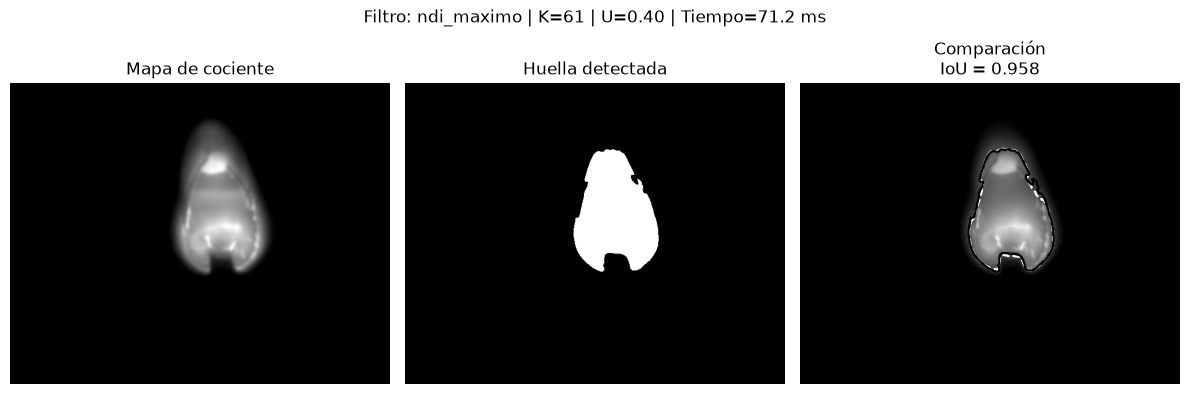

In [47]:
fila = mejores_frame1[
    mejores_frame1["filtro"] == "ndi_maximo"
].iloc[0]

iou = fila["IoU"]
K = int(fila["K"])
umbral = fila["umbral"]
tiempo = fila["tiempo_ms"]
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Datos para cada subplot
imagenes = [
    (razon, "Mapa de cociente", {"cmap":"gray","vmin":0,"vmax":1}),
    (huella, "Huella detectada", {"cmap":"gray"}),
    (frame1, f"Comparación\nIoU = {iou:.3f}", {"cmap":"gray"})
]

for ax, (img, title, params) in zip(axes, imagenes):
    ax.imshow(img, **params)
    ax.set_title(title)
    ax.axis("off")

# Contornos en el tercer subplot
axes[2].contour(mascara_frame1, levels=[0.5], colors="white", linestyles="--", linewidths=1.5)
axes[2].contour(huella, levels=[0.5], colors="black", linestyles="-", linewidths=1.5)

plt.suptitle(
    f"Filtro: ndi_maximo | K={K} | U={umbral:.2f} | Tiempo={tiempo:.1f} ms",
    fontsize=12,
    y=1.02  # desplaza el título hacia arriba
)
plt.tight_layout()
plt.show()

## Visualización - Mejor Configuración Frame 2

In [48]:
# Obtener mejor configuración para Frame 2
mejor_frame2 = mejores_frame2.iloc[0]
nombre_filtro = mejor_frame2["filtro"]
# Recalcular con mejor configuración
fs2 = ndi.gaussian_filter(frame2, 1.5)

if nombre_filtro == "cv2_gaussiano":
    parametro = mejor_frame2["sigma"]
else:
    parametro = mejor_frame2["K"]


referencia = filtros[nombre_filtro](fs2,parametro)
razon = fs2 / np.maximum(referencia,1)

huella = razon > mejor_frame2["umbral"]

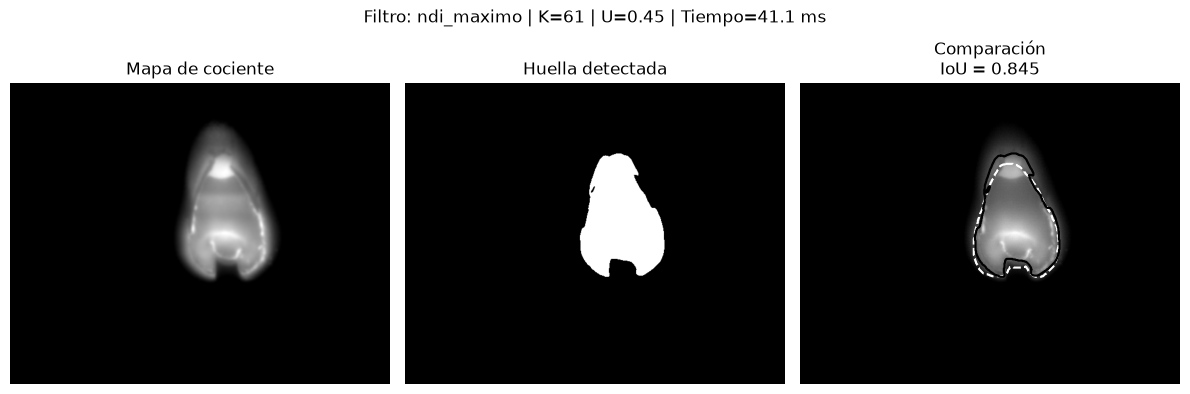

In [49]:
fila = mejores_frame2[mejores_frame2["filtro"] == "ndi_maximo"].iloc[0]

iou = fila["IoU"]
K = int(fila["K"])
umbral = fila["umbral"]
tiempo = fila["tiempo_ms"]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Datos para cada subplot
imagenes = [
    (razon, "Mapa de cociente", {"cmap":"gray","vmin":0,"vmax":1}),
    (huella, "Huella detectada", {"cmap":"gray"}),
    (frame2, f"Comparación\nIoU = {iou:.3f}", {"cmap":"gray"})
]

for ax, (img, title, params) in zip(axes, imagenes):
    ax.imshow(img, **params)
    ax.set_title(title)
    ax.axis("off")

# Contornos en el tercer subplot
axes[2].contour(mascara_frame2, levels=[0.5], colors="white", linestyles="--", linewidths=1.5)
axes[2].contour(huella, levels=[0.5], colors="black", linestyles="-", linewidths=1.5)

plt.suptitle(
    f"Filtro: ndi_maximo | K={K} | U={umbral:.2f} | Tiempo={tiempo:.1f} ms",
    fontsize=12,
    y=1.02  # desplaza el título hacia arriba
)
plt.tight_layout()
plt.show()

## Aplicación en secuencia

**Mediana 3 × 3 → máximo local → cociente**

In [25]:
def cascada_mediana_maximo_cociente (fs, K):
    paso1 = ndi.median_filter(fs, size=3) # suavizado, píxeles calientes aislados
    paso2 = filtro_maximo(paso1, K) # referencia local
    razon = paso1 / np.maximum(paso2, 1) # cociente
    return razon

**Cociente → umbral → apertura binaria pequeña**

In [26]:
def cascada_cociente_umbral_apertura(razon, umbral, tam = 3):
    huella = razon > umbral # aplicar umbral al cociente
    kernel = np.ones((tam, tam), dtype=np.uint8) # elemento estructurante pequeño
    huella_apertura = cv2.morphologyEx(huella.astype(np.uint8), cv2.MORPH_OPEN, kernel) # apertura binaria
    return huella_apertura.astype(bool)


**Máximo local → gaussiano grande sobre la referencia → cociente**

In [27]:
def cascada_maximo_gaussiano_cociente (fs, K, sigma = 10):
    paso1 = filtro_maximo(fs, K) # referencia local
    paso2 = cv2.GaussianBlur(paso1, (0, 0), sigma) # suavizado gaussiano
    razon = fs / np.maximum(paso2, 1) # cociente
    return razon

**Dos referencias (máximo y percentil 90) → promedio de los dos cocientes**

In [28]:
def cascada_maximo_percentil90_promcocientes(fs, K):
    paso1 = filtro_maximo(fs, K) # referencia local
    paso2 = filtro_percentil90(fs, K) # referencia robusta   
    razon_max = fs / np.maximum(paso1, 1) # cociente máximo
    razon_percentil90 = fs / np.maximum(paso2, 1) # cociente percentil 90
    razon_promedio = (razon_max + razon_percentil90) / 2 # promedio de los dos cocientes
    return razon_promedio

In [29]:
cascadas = {
    "cascada_mediana_maximo_cociente": cascada_mediana_maximo_cociente,
    "cascada_maximo_gaussiano_cociente": cascada_maximo_gaussiano_cociente,
    "cascada_maximo_percentil90_promcocientes": cascada_maximo_percentil90_promcocientes
}

## Cascada - FRAME 1

In [30]:
# Preprocesamiento Frame 1
fs1_cascada = ndi.gaussian_filter(frame1, 1.5)

# Barrido de cascadas
resultados_frame1_cascada = []

for nombre_cascada in cascadas.keys():
    print(f"\nProcesando: {nombre_cascada}")
    for K in Grupo_K:
        t0 = time.perf_counter()
        razon = cascadas[nombre_cascada](fs1_cascada, K)
        dt = (time.perf_counter() - t0) * 1000
        for umbral in np.arange(0.30, 1.01, 0.05):
            huella = razon > umbral
            iou = calcular_iou(mascara_frame1, huella)
            resultado = {
                "frame": 1,
                "cascada": nombre_cascada,
                "K": K,
                "umbral": umbral,
                "IoU": iou,
                "tiempo_ms": dt
            }
            resultados_frame1_cascada.append(resultado)
    
    # Mostrar mejor de cascada
    mejores = [r for r in resultados_frame1_cascada if r['cascada'] == nombre_cascada]
    mejor = max(mejores, key=lambda x: x['IoU'])
    print(f"  Mejor IoU: {mejor['IoU']:.3f}")


Procesando: cascada_mediana_maximo_cociente
  Mejor IoU: 0.958

Procesando: cascada_maximo_gaussiano_cociente
  Mejor IoU: 0.958

Procesando: cascada_maximo_percentil90_promcocientes
  Mejor IoU: 0.936


**Nota**: La cascada Cociente → umbral → apertura binaria pequeña, parte de una razón que debe ser calculada previamente, por lo que se trata a parte, tomando la razon del mejor filtro individual seleccionado en el anterior punto.

In [31]:
referencia = filtro_maximo(fs1_cascada, 61) # Referencia para el cociente
razon = fs1_cascada / np.maximum(referencia, 1) # cociente 

t0 = time.perf_counter()
resultados_frame1_apertura = []

for umbral in np.arange(0.30, 1.01, 0.05):
    huella = cascada_cociente_umbral_apertura(razon, umbral, tam=3)
    dt = (time.perf_counter() - t0) * 1000
    iou = calcular_iou(mascara_frame1, huella)
    resultados_frame1_apertura.append({
        "frame": 1,
        "cascada": "cascada_cociente_umbral_apertura",
        "K": 61,
        "umbral": umbral,
        "IoU": iou,
        "tiempo_ms": dt
    })
    resultados_frame1_cascada.append(resultados_frame1_apertura[-1])

# Mostrar mejor de cascada
mejores = [r for r in resultados_frame1_apertura]
mejor = max(mejores, key=lambda x: x['IoU'])
print(f"  Mejor IoU: {mejor['IoU']:.3f}")

  Mejor IoU: 0.959


In [32]:
df_resultados_frame1_cascada = pd.DataFrame(resultados_frame1_cascada)

mejores = (
    df_resultados_frame1_cascada.loc[df_resultados_frame1_cascada.groupby("cascada")["IoU"].idxmax()]
      .sort_values("IoU", ascending=False)
)

print("\nMEJORES CONFIGURACIONES - CASCADAS FRAME 1:")
print(mejores[["cascada", "K", "umbral", "IoU", "tiempo_ms"]].to_string(index=False))


MEJORES CONFIGURACIONES - CASCADAS FRAME 1:
                                 cascada  K  umbral      IoU  tiempo_ms
        cascada_cociente_umbral_apertura 61     0.4 0.958592    46.0060
         cascada_mediana_maximo_cociente 61     0.4 0.958184    33.3177
       cascada_maximo_gaussiano_cociente 61     0.4 0.957741    31.8149
cascada_maximo_percentil90_promcocientes 61     0.5 0.936182  3349.3559


## Cascada - FRAME 2

In [33]:
# Preprocesamiento Frame 2
fs2_cascada = ndi.gaussian_filter(frame2, 1.5)

# Barrido de cascadas
resultados_frame2_cascada = []

for nombre_cascada in cascadas.keys():
    print(f"\nProcesando: {nombre_cascada}")
    for K in Grupo_K:
        t0 = time.perf_counter()
        razon = cascadas[nombre_cascada](fs2_cascada, K)
        dt = (time.perf_counter() - t0) * 1000
        for umbral in np.arange(0.30, 1.01, 0.05):
            huella = razon > umbral
            iou = calcular_iou(mascara_frame2, huella)
            resultado = {
                "frame": 2,
                "cascada": nombre_cascada,
                "K": K,
                "umbral": umbral,
                "IoU": iou,
                "tiempo_ms": dt
            }
            resultados_frame2_cascada.append(resultado)
    
    # Mostrar mejor de cascada
    mejores = [r for r in resultados_frame2_cascada if r['cascada'] == nombre_cascada]
    mejor = max(mejores, key=lambda x: x['IoU'])
    print(f"  Mejor IoU: {mejor['IoU']:.3f}")


Procesando: cascada_mediana_maximo_cociente
  Mejor IoU: 0.847

Procesando: cascada_maximo_gaussiano_cociente
  Mejor IoU: 0.842

Procesando: cascada_maximo_percentil90_promcocientes
  Mejor IoU: 0.846


In [34]:
referencia = filtro_maximo(fs2_cascada, 61) # Referencia para el cociente
razon = fs2_cascada / np.maximum(referencia, 1) # cociente 

t0 = time.perf_counter()
resultados_frame2_apertura = []

for umbral in np.arange(0.30, 1.01, 0.05):
    huella = cascada_cociente_umbral_apertura(razon, umbral, tam=3)
    dt = (time.perf_counter() - t0) * 1000
    iou = calcular_iou(mascara_frame2, huella)
    resultados_frame2_apertura.append({
        "frame": 2,
        "cascada": "cascada_cociente_umbral_apertura",
        "K": 61,
        "umbral": umbral,
        "IoU": iou,
        "tiempo_ms": dt
    })
    resultados_frame2_cascada.append(resultados_frame2_apertura[-1])

# Mostrar mejor de cascada
mejores = [r for r in resultados_frame2_apertura]
mejor = max(mejores, key=lambda x: x['IoU'])
print(f"  Mejor IoU: {mejor['IoU']:.3f}")

  Mejor IoU: 0.845


In [35]:
df_resultados_frame2_cascada = pd.DataFrame(resultados_frame2_cascada)

mejores = (
    df_resultados_frame2_cascada.loc[df_resultados_frame2_cascada.groupby("cascada")["IoU"].idxmax()]
      .sort_values("IoU", ascending=False)
)

print("\nMEJORES CONFIGURACIONES - CASCADAS FRAME 2:")
print(mejores[["cascada", "K", "umbral", "IoU", "tiempo_ms"]].to_string(index=False))


MEJORES CONFIGURACIONES - CASCADAS FRAME 2:
                                 cascada  K  umbral      IoU  tiempo_ms
         cascada_mediana_maximo_cociente 61    0.45 0.846507    34.2697
cascada_maximo_percentil90_promcocientes 61    0.55 0.846423  3250.4726
        cascada_cociente_umbral_apertura 61    0.45 0.844687    12.2532
       cascada_maximo_gaussiano_cociente 41    0.55 0.841578    28.6313


## Comparación Global Cascadas

In [36]:
# Combinar resultados de ambos frames
df_todos_cascada = pd.concat([df_resultados_frame1_cascada, df_resultados_frame2_cascada], ignore_index=True)

# Tabla resumen
resumen = df_todos_cascada.groupby('cascada').agg({
    'IoU': ['max', 'min', 'mean'],
    'tiempo_ms': 'mean'
}).round(3)

print("\nRESUMEN POR FILTRO (ambos frames):")
print(resumen)


RESUMEN POR FILTRO (ambos frames):
                                            IoU              tiempo_ms
                                            max   min   mean      mean
cascada                                                               
cascada_cociente_umbral_apertura          0.959  0.00  0.434    38.692
cascada_maximo_gaussiano_cociente         0.958  0.00  0.505    28.945
cascada_maximo_percentil90_promcocientes  0.936  0.01  0.548  1745.738
cascada_mediana_maximo_cociente           0.958  0.00  0.499    36.477


In [37]:
# Mejor configuración global por IoU promedio
promedio_por_config_cas = (df_todos_cascada.groupby(["cascada", "K", "umbral"]).agg({"IoU": "mean",
    "tiempo_ms": "mean"
    })
    .reset_index()
)

mejor_global = promedio_por_config_cas.loc[
    promedio_por_config_cas["IoU"].idxmax()
]

print("\nMEJOR CONFIGURACIÓN GLOBAL:")
print(f"Cascada: {mejor_global['cascada']}")
print(f"K: {int(mejor_global['K'])}")
print(f"Umbral: {mejor_global['umbral']:.2f}")
print(f"IoU promedio: {mejor_global['IoU']:.3f}")
print(f"Tiempo promedio: {mejor_global['tiempo_ms']:.1f} ms")


MEJOR CONFIGURACIÓN GLOBAL:
Cascada: cascada_cociente_umbral_apertura
K: 61
Umbral: 0.40
IoU promedio: 0.894
Tiempo promedio: 27.5 ms


In [38]:
nombre_cascada = mejor_global["cascada"]
K = int(mejor_global["K"])
umbral = mejor_global["umbral"]

# FRAME 1
ref1 = filtro_dilatacion(fs1, K)
razon1 = fs1 / np.maximum(ref1, 1)
huella1 = cascada_cociente_umbral_apertura(razon1, umbral, tam=3)

# FRAME 2
ref2 = filtro_dilatacion(fs2, K)
razon2 = fs2 / np.maximum(ref2, 1)
huella2 = cascada_cociente_umbral_apertura(razon2, umbral, tam=3)


iou1 = calcular_iou(mascara_frame1, huella1)
iou2 = calcular_iou(mascara_frame2, huella2)

print(f"Cascada: {nombre_cascada}")
print(f"K: {K}")
print(f"Umbral: {umbral:.2f}")
print(f"IoU Frame 1: {iou1:.3f}")
print(f"IoU Frame 2: {iou2:.3f}")

Cascada: cascada_cociente_umbral_apertura
K: 61
Umbral: 0.40
IoU Frame 1: 0.937
IoU Frame 2: 0.819


In [39]:
# Mejor configuración de cada filtro
mejores_por_filtro_cascada = (
    promedio_por_config_cas.loc[
        promedio_por_config_cas.groupby('cascada')['IoU'].idxmax()
    ]
    .sort_values('IoU', ascending=False)
)

mejores_por_filtro_cascada

,cascada,K,umbral,IoU,tiempo_ms
2,cascada_cociente_umbral_apertura,61,0.40,0.894448,27.53675
137,cascada_mediana_maximo_cociente,61,0.40,0.893679,33.79370
48,cascada_maximo_gaussiano_cociente,61,0.45,0.893500,28.45305
94,cascada_maximo_percentil90_promcocientes,61,0.50,0.883657,3299.91425


## Visualización - Mejor Configuración Cascadas Global

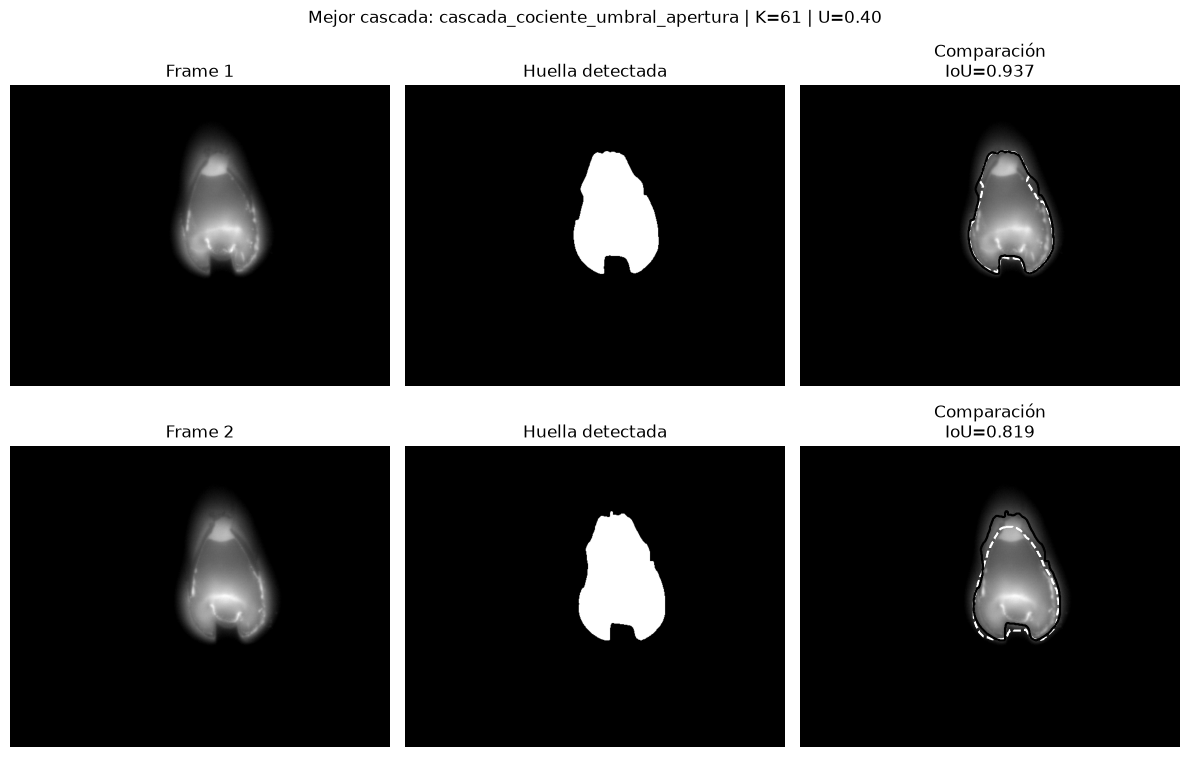

In [40]:
fig, ax = plt.subplots(2, 3, figsize=(12, 8))
frames=[frame1,frame2];huellas=[huella1,huella2];mascaras=[mascara_frame1,mascara_frame2];ious=[iou1,iou2]

for i,(f,h,m,iou) in enumerate(zip(frames,huellas,mascaras,ious)):
    ax[i,0].imshow(f,cmap="gray");ax[i,0].set_title(f"Frame {i+1}");ax[i,0].axis("off")
    ax[i,1].imshow(h,cmap="gray");ax[i,1].set_title("Huella detectada");ax[i,1].axis("off")
    ax[i,2].imshow(f,cmap="gray")
    ax[i,2].contour(m,levels=[0.5],colors="white",linestyles="--",linewidths=1.5)
    ax[i,2].contour(h,levels=[0.5],colors="black",linewidths=1.5)
    ax[i,2].set_title(f"Comparación\nIoU={iou:.3f}");ax[i,2].axis("off")

plt.suptitle(f"Mejor cascada: {nombre_cascada} | K={K} | U={umbral:.2f}",fontsize=12)
plt.tight_layout();plt.show()

# Resumen

Para este dataset, se recomienda el filtro ndi_maximo con K = 61 y un umbral de 0.40. Entre los filtros evaluados, obtuvo el mejor desempeño global, un IoU promedio de 0.894 y un tiempo de procesamiento cercano a 21.8 ms. Estos resultados indican que la referencia basada en el máximo local representa adecuadamente el brillo de la huella cercana y permite separarla de forma consistente del halo. Además, el filtro mantuvo un desempeño estable en los dos frames analizados, tanto de manera individual como dentro de cascadas.

La cascada con mejor resultado fue cociente → umbral → apertura binaria, con un IoU de 0.894448 y un tiempo aproximado de 27.5 ms. La mejora respecto al filtro individual fue mínima, por lo que no aumentó de forma relevante la precisión. No obstante, la apertura morfológica elimina pequeñas regiones aisladas generadas tras el umbral y produce una máscara más limpia sin alterar de manera significativa la forma principal de la huella. Su uso en secuencia es conveniente cuando cada operación cumple una función clara y el costo computacional se mantiene bajo. En cambio, aunque la cascada que incorpora el percentil 90 alcanzó un IoU favorable, su mayor tiempo de procesamiento la hace menos práctica para analizar una gran cantidad de frames.

Para convertir los datos a temperatura, deben conservarse los valores originales del frame uint16 o una copia en float32. No deben usarse los valores de la máscara, del cociente ni de las imágenes filtradas, estos elementos sirven únicamente para identificar los píxeles pertenecientes a la huella. El procedimiento recomendado según lo aplicado en el taller es conservar el frame original, calcular la referencia local y el cociente sobre una copia suavizada, generar la máscara y utilizarla para seleccionar los valores originales que se convertirán a temperatura. Así se evita alterar las intensidades físicas durante el procesamiento espacial.

Finalmente, el análisis de las sombras observadas permitió distinguir dos mecanismos. La sombra proximal a la huella refleja la distribución térmica real, producida por la propagación de la energía del láser hacia el material circundante. En cambio, la sombra distal y difusa se debe a artefactos ópticos de la cámara SWIR, como la reflexión y la dispersión de la radiación. Esta distinción puede validarse mediante un análisis temporal: la señal térmica se atenúa gradualmente después de la irradiación, mientras que los artefactos ópticos desaparecen al cesar la exposición.